# Utilization Prediction

## a) Business Case

During the descriptives task, we defined three KPIs:

1) Utilization rate
2) Energy delivered per hour
3) Rate of registered user sessions

The business case behind these KPIs is defined as:

<br><br>
<center>
  <b style="font-size: 1.3em;">
    The prediction model enables the site operator to offer dynamic pricing to registered users to maximize revenue and energy throughput while smoothing demand.
  </b>
</center>
<br><br>

The model predicts the hourly utilization of a given site. This information can be used to offer dynamic pricing models: when utilization and energy delivered are low, prices can be lowered to encourage usage. Notifications can be sent to registered users, e.g. through an app, to increase engagement, improve site utilization and maximize energy throughput.


## b) Prediction Model

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns
import holidays
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "df_prepared.pkl", "rb") as f:
    df = pickle.load(f)

with open(data_path + "merged_df_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

with open(data_path + "relevant_weather_data_prepared.pkl", "rb") as f:
    relevant_weather_data = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  df shape: {df.shape}")
print(f"  merged_df shape: {merged_df.shape}")
print(f"  relevant_weather_data shape: {relevant_weather_data.shape}")

DataFrames loaded successfully:
  df shape: (65006, 21)
  merged_df shape: (65006, 27)
  relevant_weather_data shape: (26187, 9)


We choose site 1 for this task

In [2]:
print(merged_df.siteID.unique())
print(merged_df.stationID.dtype)
df_site_1 = merged_df[merged_df['siteID'] == '1']
df_site_1 = df_site_1.sort_values(by='connectionTime', ascending=True)
df_site_1.head()


['1' '2']
object


,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,userID,...,session_duration,charging_duration,isRegisteredUser,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
11686,5c36621bf9af8b4639a8e0b4,2018-09-05 04:04:13-07:00,2018-09-05 12:09:35-07:00,2018-09-05 12:09:35-07:00,9.583,1_1_179_800_2018-09-05 11:04:12.876087,1,ag-3f32,1-1-179-800,-1,...,8.089444,8.089444,False,NaN,NaN,NaN,NaN,NaT,NaN,NaT
8985,5c36621bf9af8b4639a8e0b5,2018-09-05 04:08:09-07:00,2018-09-05 07:09:02-07:00,2018-09-05 07:09:02-07:00,7.114,1_1_179_794_2018-09-05 11:08:08.945820,1,ag-3f20,1-1-179-794,333.0,...,3.014722,3.014722,True,400.0,8.0,20.0,421.0,2018-09-05 06:32:58-07:00,True,2018-09-05 11:09:09-07:00
10020,5c36621bf9af8b4639a8e0b6,2018-09-05 05:35:14-07:00,2018-09-05 17:30:12-07:00,2018-09-05 17:30:12-07:00,11.774,1_1_179_797_2018-09-05 12:35:14.070250,1,ag-3f23,1-1-179-797,371.0,...,11.916111,11.916111,True,600.0,24.0,40.0,643.0,2018-09-05 06:16:35-07:00,True,2018-09-05 16:18:14-07:00
5685,5c36621bf9af8b4639a8e0b7,2018-09-05 05:51:31-07:00,2018-09-05 15:32:58-07:00,2018-09-05 15:32:58-07:00,6.280,1_1_179_781_2018-09-05 12:51:31.050539,1,ag-3f31,1-1-179-781,405.0,...,9.690833,9.690833,True,500.0,10.0,20.0,576.0,2018-09-05 14:10:15-07:00,True,2018-09-05 15:27:31-07:00
6810,5c36621bf9af8b4639a8e0b8,2018-09-05 06:08:28-07:00,2018-09-05 16:32:52-07:00,2018-09-05 16:32:52-07:00,7.022,1_1_179_787_2018-09-05 13:08:27.901538,1,ag-3f16,1-1-179-787,368.0,...,10.406667,10.406667,True,400.0,8.0,20.0,608.0,2018-09-05 06:36:15-07:00,True,2018-09-05 16:16:28-07:00


In [3]:
mask = df['charging_duration'] == df['session_duration']
anzahl = df[mask].shape[0]
print(f"Anzahl der Sitzungen, bei denen die Ladedauer gleich der Sitzungsdauer ist: {anzahl}")

Anzahl der Sitzungen, bei denen die Ladedauer gleich der Sitzungsdauer ist: 8479


In [4]:
print(df_site_1['stationID'].nunique())

52


## Calculate Utilization for all hour where there was a session

In [5]:
def make_site1_hourly_utilization(df,
                                  conn_col='connectionTime',
                                  disc_col='disconnectTime',
                                  station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start:
            return []
        hours = pd.date_range(
            start=start.floor('H'),
            end=(end - pd.Timedelta(seconds=1)).floor('H'),
            freq='H'
        )
        out = []
        for h in hours:
            h_start = max(start, h)
            h_end = min(end, h + pd.Timedelta(hours=1))
            minutes = (h_end - h_start).total_seconds() / 60.0
            if minutes > 0:
                out.append((h, minutes))
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame(
        [{'datetime': h, 'minutes': m}
         for lst in contrib for (h, m) in lst]
    )

    if tmp.empty:
        hourly = pd.DataFrame(
            columns=['datetime', 'hourly_utilization_minutes',
                     'hourly_utilization']
        )
        hourly['datetime'] = pd.to_datetime(hourly['datetime'])
        return hourly.set_index('datetime')

    # 1) Aggregation: eine Zeile pro Stunde
    hourly = (
        tmp.groupby('datetime')['minutes']
        .sum()
        .rename('hourly_utilization_minutes')
        .to_frame()
    )

    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_minutes'] / (n_stations * 60.0)
    ).clip(0, 1)



    return hourly



In [6]:
# Compute hourly utilization for site 1 using connectionTime & disconnectTime
df_site_1_util = make_site1_hourly_utilization(df_site_1, 'connectionTime', 'disconnectTime')
df_site_1 = df_site_1.sort_values(by='connectionTime', ascending=True)


C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\3120264220.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=start.floor('H'),
C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\3120264220.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=(end - pd.Timedelta(seconds=1)).floor('H'),
C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\3120264220.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(


In [7]:
df_site_1_util.head()


,hourly_utilization_minutes,hourly_utilization
datetime,,
2018-09-05 04:00:00-07:00,107.633333,0.034498
2018-09-05 05:00:00-07:00,153.250000,0.049119
2018-09-05 06:00:00-07:00,469.800000,0.150577
2018-09-05 07:00:00-07:00,874.300000,0.280224
2018-09-05 08:00:00-07:00,900.000000,0.288462


## Holidays

**pip install holidays runnen**

In [8]:
US_holidays = holidays.US(state='CA')

df_site_1_util['is_holiday'] = df_site_1_util.index.to_series().apply(lambda dt: dt in US_holidays)
df_site_1_util['holiday_name'] = df_site_1_util.index.to_series().apply(lambda dt: US_holidays.get(dt) if dt in US_holidays else '')

df_site_1_util.head()



,hourly_utilization_minutes,hourly_utilization,is_holiday,holiday_name
datetime,,,,
2018-09-05 04:00:00-07:00,107.633333,0.034498,False,
2018-09-05 05:00:00-07:00,153.250000,0.049119,False,
2018-09-05 06:00:00-07:00,469.800000,0.150577,False,
2018-09-05 07:00:00-07:00,874.300000,0.280224,False,
2018-09-05 08:00:00-07:00,900.000000,0.288462,False,


## Create hourly data of sessions

In [9]:
def make_site1_hourly_features(df,
                               conn_col='connectionTime',
                               disc_col='disconnectTime',
                               station_col='stationID'):
    df = df.copy()
    df[conn_col] = pd.to_datetime(df[conn_col], errors='coerce')
    df[disc_col] = pd.to_datetime(df[disc_col], errors='coerce')

    n_stations = df[station_col].nunique()

    def row_hour_contrib(row):
        start = row[conn_col]
        end = row[disc_col]
        if pd.isna(start) or pd.isna(end) or end <= start:
            return []

        hours = pd.date_range(
            start=start.floor('H'),
            end=(end - pd.Timedelta(seconds=1)).floor('H'),
            freq='H'
        )

        out = []
        for h in hours:
            h_start = max(start, h)
            h_end = min(end, h + pd.Timedelta(hours=1))
            minutes = (h_end - h_start).total_seconds() / 60.0
            if minutes > 0:
                out.append({
                    'datetime': h,
                    'minutes': minutes,
                    'kWhDelivered': row['kWhDelivered'],
                    'userID': row['userID'],
                    'siteID': row[station_col],
                    'is_registered': row['isRegisteredUser'],
                    'session_duration': row['session_duration'],
                    'charging_duration': row['charging_duration']

                })
        return out

    contrib = df.apply(row_hour_contrib, axis=1)
    tmp = pd.DataFrame([item for lst in contrib for item in lst])

    if tmp.empty:
        return pd.DataFrame(columns=[
            'datetime', 'hourly_utilization_minutes', 'hourly_utilization'
        ]).set_index('datetime')

    # Stundenaggregation für Nutzung + zusätzliche Features
    hourly = (
        tmp.groupby('datetime')
            .agg(
                hourly_utilization_minutes=('minutes', 'sum'),
                energy_kwh_hour=('kWhDelivered', 'sum'),
                avg_kwh_per_session=('kWhDelivered', 'mean'),
                avg_session_duration=('session_duration', 'mean'),
                avg_charging_duration=('charging_duration', 'mean'),
                n_sessions=('userID', 'nunique'),
                n_registered_sessions=('is_registered', 'sum')
            )
    )

    hourly['hourly_utilization'] = (
        hourly['hourly_utilization_minutes'] / (n_stations * 60.0)
    ).clip(0, 1)

    return hourly

    

In [10]:
df_site_1_features = make_site1_hourly_features(df_site_1, 'connectionTime', 'disconnectTime')
df_site_1_features.head()

C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\670990831.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start=start.floor('H'),
C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\670990831.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=(end - pd.Timedelta(seconds=1)).floor('H'),
C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\670990831.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(


,hourly_utilization_minutes,energy_kwh_hour,avg_kwh_per_session,avg_session_duration,avg_charging_duration,n_sessions,n_registered_sessions,hourly_utilization
datetime,,,,,,,,
2018-09-05 04:00:00-07:00,107.633333,16.697,8.348500,5.552083,5.552083,2,1,0.034498
2018-09-05 05:00:00-07:00,153.250000,34.751,8.687750,8.177778,8.177778,4,3,0.049119
2018-09-05 06:00:00-07:00,469.800000,110.399,10.036273,8.564394,8.564394,10,9,0.150577
2018-09-05 07:00:00-07:00,874.300000,158.350,9.896875,8.464219,8.464219,10,9,0.280224
2018-09-05 08:00:00-07:00,900.000000,151.236,10.082400,8.827519,8.827519,9,8,0.288462


In [11]:
df_site_1_features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16123 entries, 2018-09-05 04:00:00-07:00 to 2021-09-14 07:00:00-07:00
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hourly_utilization_minutes  16123 non-null  float64
 1   energy_kwh_hour             16123 non-null  float64
 2   avg_kwh_per_session         16123 non-null  float64
 3   avg_session_duration        16123 non-null  float64
 4   avg_charging_duration       16123 non-null  float64
 5   n_sessions                  16123 non-null  int64  
 6   n_registered_sessions       16123 non-null  int64  
 7   hourly_utilization          16123 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 1.1 MB


## Feature Selection

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_site_1_features.copy()
df_plot['day_name'] = df_plot.index.day_name()
df_plot['hour'] = df_plot.index.hour
df_plot['month_name'] = df_plot.index.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

### Averga Utiliuation by day of Week

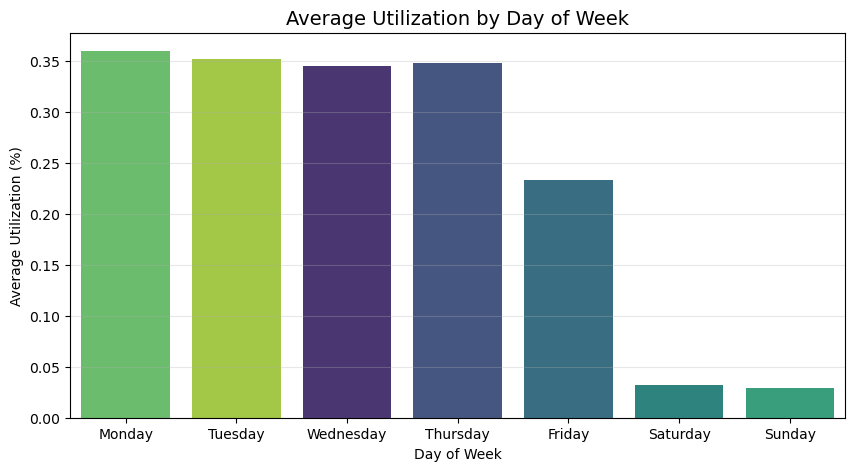

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot, 
    x='day_name', 
    y='hourly_utilization', 
    order=day_order, 
    palette='viridis', 
    hue='day_name',
    legend=False,
    errorbar=None
)
plt.title('Average Utilization by Day of Week', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Day of Week')
plt.grid(axis='y', alpha=0.3)
plt.show()

The data shows big contrast between high week utilization and near zero weekend usage. Therefore, we asssume day of the week to be a useful predictor of utilization.

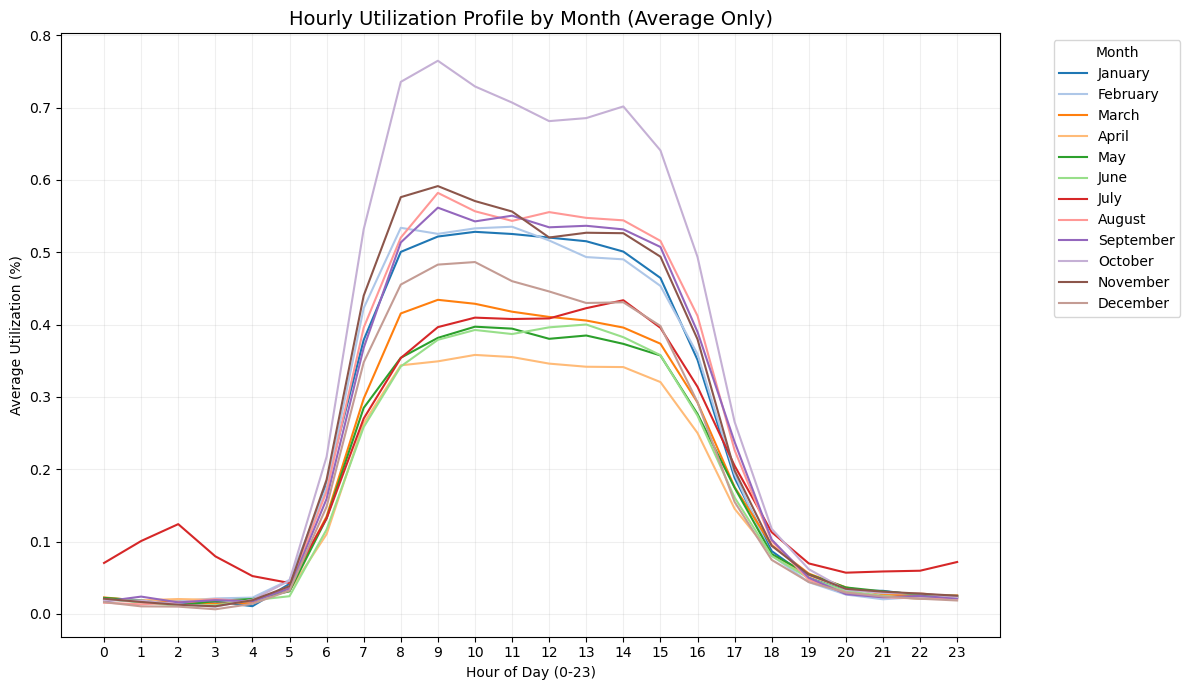

In [14]:
plt.figure(figsize=(12, 7))

sns.lineplot(data=df_plot, x='hour', y='hourly_utilization', 
             hue='month_name', hue_order=month_order, 
             palette='tab20', errorbar=None)

plt.title('Hourly Utilization Profile by Month (Average Only)', fontsize=14)
plt.ylabel('Average Utilization (%)')
plt.xlabel('Hour of Day (0-23)')
plt.xticks(range(0, 24))
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

As shown in the Figure above, the average utilization varies significantly at different times of the day. This temporal variation highlights the importance of including a hour of the day feature in the model, enabling the model to learn patterns based on the time of the day. Similarly, the data displays seasonal fluctuations and across different months. This monthly variation necessitates the inclusion of a month feature to allow the model to capture recurring seasonal patterns.

## Feature Engineering

### Add before covid boolean

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify the Gap
# We calculate the time difference between each row
time_diffs = df_site_1_features.index.to_series().diff()

# The largest gap will be our COVID period
gap_end = time_diffs.idxmax()
gap_start = df_site_1_features.index[df_site_1_features.index.get_loc(gap_end) - 1]

print(f"Gap detected between: {gap_start} and {gap_end}")
print(f"Total gap duration: {gap_end - gap_start}")

# 2. Add 'before_covid' column
# 1 if before the gap start, 0 if after (or at) the gap end
df_site_1_features['before_covid'] = (df_site_1_features.index <= gap_start).astype(int)

# Verify the split
print("\nValue counts for 'before_covid':")
print(df_site_1_features['before_covid'].value_counts())

Gap detected between: 2020-08-03 21:00:00-07:00 and 2020-11-18 12:00:00-08:00
Total gap duration: 106 days 16:00:00

Value counts for 'before_covid':
before_covid
1    11339
0     4784
Name: count, dtype: int64


C:\Users\dan20\AppData\Local\Temp\ipykernel_43796\2494693093.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df_site_1_features.index.min(),


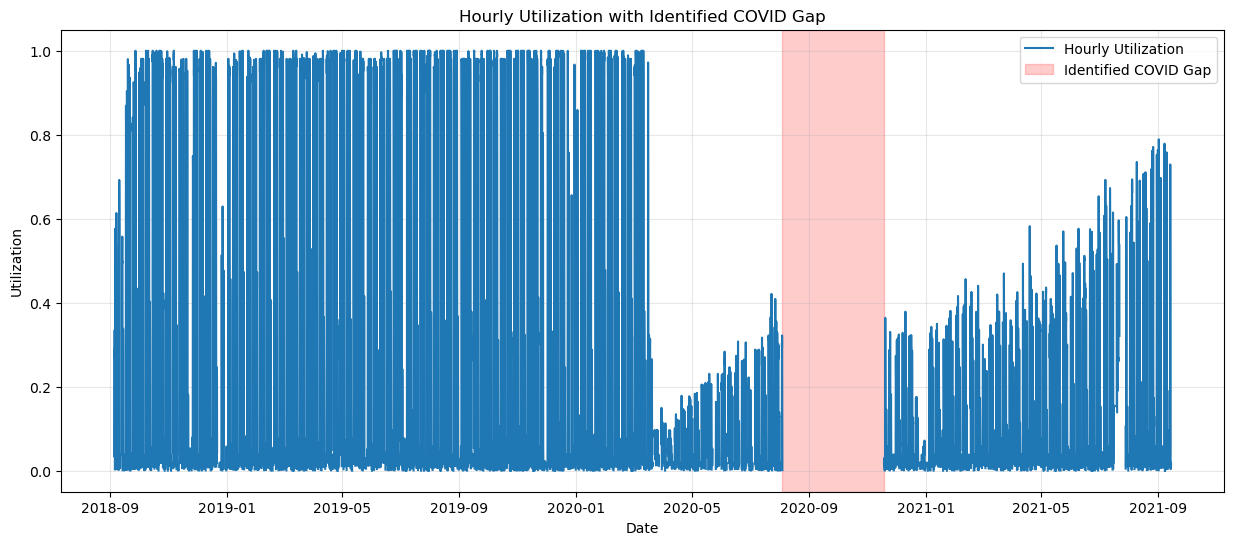

In [16]:
# Create a continuous hourly range from the very start to the very end
full_range = pd.date_range(start=df_site_1_features.index.min(), 
                           end=df_site_1_features.index.max(), 
                           freq='H')

# Reindex to show where the gaps are (will fill missing hours with NaN)
df_reindexed = df_site_1_features.reindex(full_range)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_reindexed.index, df_reindexed['hourly_utilization'], label='Hourly Utilization', color='tab:blue')

# Highlight the gap
plt.axvspan(gap_start, gap_end, color='red', alpha=0.2, label='Identified COVID Gap')

plt.title('Hourly Utilization with Identified COVID Gap')
plt.xlabel('Date')
plt.ylabel('Utilization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# 1. Calculate the time difference between consecutive rows
# this helps find the largest gap in the Datetime Index
time_diffs = df_site_1_features.index.to_series().diff()

# 2. Identify the timestamp where the data resumes after the gap
gap_end_timestamp = time_diffs.idxmax()

print(f"Data resumes after gap at: {gap_end_timestamp}")

# 3. Create the 'before_covid' column
# It assigns 1 to all timestamps before the gap, and 0 to all those after
df_site_1_features['before_covid'] = (df_site_1_features.index < gap_end_timestamp).astype(int)
print(df_site_1_features['before_covid'].value_counts())

Data resumes after gap at: 2020-11-18 12:00:00-08:00
before_covid
1    11339
0     4784
Name: count, dtype: int64


### Add holiday, month, day of week, hour of day features

We add a feature for holidays as this  influence the utilization due to the fact that employees do not work at this and university is also closed there. Additionally we add the already know time features from the session dataset.

In [18]:
US_holidays = holidays.US(state='CA')

# Ensure index is datetime
df_site_1_features.index = pd.to_datetime(df_site_1_features.index)

df_site_1_features['is_holiday'] = df_site_1_features.index.to_series().apply(lambda dt: dt in US_holidays)
df_site_1_features['holiday_name'] = df_site_1_features.index.to_series().apply(lambda dt: US_holidays.get(dt) if dt in US_holidays else '')

#Add time features based on the index
df_site_1_features['year'] = df_site_1_features.index.year
df_site_1_features['month'] = df_site_1_features.index.month
df_site_1_features['day'] = df_site_1_features.index.day
df_site_1_features['hour'] = df_site_1_features.index.hour
df_site_1_features['dayofweek'] = df_site_1_features.index.dayofweek
df_site_1_features['is_weekend'] = df_site_1_features['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
df_site_1_features['season'] = df_site_1_features['month'].apply(get_season)

In [19]:
df_site_1_features['util_last_hour_flag'] = df_site_1_features['hourly_utilization'].shift(1)

df_site_1_features['util_prev_day_flag'] = df_site_1_features['hourly_utilization'].shift(24)

In [20]:
#lag_cols = ['util_last_hour_flag', 'util_prev_day_flag']
#df_site_1_features = df_site_1_features.dropna(subset=lag_cols)

## Training Test Validation Split on selected features

In [21]:
X = df_site_1_features[['hour', 'dayofweek', 'month', 'year']]#, 'util_last_hour_flag', 'util_prev_day_flag']]
y = df_site_1_features['hourly_utilization']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=1)

print(len(x_train), len(x_hold), len(x_test))

8061 3225 4837


## Modeling

### Regression Code

In [26]:
degrees = range(1, 8)
alphas = [0.01, 0.1, 1, 10]
models = ["linear", "Ridge", "Lasso"]
results = []

In [27]:
def run_models(models, degrees, alphas, 
               x_train, x_hold, y_train, y_hold):
    rows = []  # list of dicts, reusable each call

    for model in models:
        for degree in degrees:
            # create polynomial features
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_train_poly = poly.fit_transform(x_train)
            X_hold_poly = poly.transform(x_hold)

            # standardize
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_poly)
            X_hold_scaled = scaler.transform(X_hold_poly)

            if model in ["Ridge", "Lasso"]:
                for alpha in alphas:
                    if model == "Ridge":
                        reg = Ridge(alpha=alpha)
                    else:
                        reg = Lasso(alpha=alpha, max_iter=10000)

                    reg.fit(X_train_scaled, y_train)

                    y_hold_pred = reg.predict(X_hold_scaled)
                    mse_val = mean_squared_error(y_hold, y_hold_pred)
                    r2_val = r2_score(y_hold, y_hold_pred)

                    rows.append({
                        "model": model,
                        "degree": degree,
                        "alpha": alpha,
                        "mse": mse_val,
                        "r2": r2_val,
                        "poly": poly,
                        "scaler": scaler,
                        "reg": reg
                    })
            else:
                reg = LinearRegression()
                reg.fit(X_train_scaled, y_train)
                y_hold_pred = reg.predict(X_hold_scaled)
                mse_val = mean_squared_error(y_hold, y_hold_pred)

                rows.append({
                    "model": model,
                    "degree": degree,
                    "alpha": None,
                    "mse": mse_val,
                    "poly": poly,
                    "scaler": scaler,
                    "reg": reg
                })

    return pd.DataFrame(rows)


In [28]:
results = run_models(models, degrees, alphas, x_train, x_hold, y_train, y_hold)
best_idx = results["r2"].idxmax()
best_model = results.loc[best_idx]

print(best_model)

model                                                Ridge
degree                                                   7
alpha                                                 0.01
mse                                               0.037496
poly      PolynomialFeatures(degree=7, include_bias=False)
scaler                                    StandardScaler()
reg                                      Ridge(alpha=0.01)
r2                                                 0.68978
Name: 31, dtype: object


In [29]:
best_poly = best_model['poly']
best_scaler = best_model['scaler']
best_reg = best_model['reg']

X_test_poly = best_poly.transform(x_test)
X_test_scaled = best_scaler.transform(X_test_poly)

y_test_pred = best_reg.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Test MSE: {mse_test}")
print(f"Test R2: {r2_test}")


Test MSE: 0.03847390368718536
Test R2: 0.6774672862657154


### Decision Tree Code

In [30]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# 1. Initialize a basic tree
regr = DecisionTreeRegressor(random_state=42)

# 2. Get the pruning path
path = regr.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [32]:
# 3. Use these alphas in Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'ccp_alpha': ccp_alphas[::5], # Subsample alphas to speed up search
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(x_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'ccp_alpha': array([0.0000...90453484e-04]), 'min_samples_leaf': [5, 10, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


<Axes: title={'center': 'Feature Importance'}>

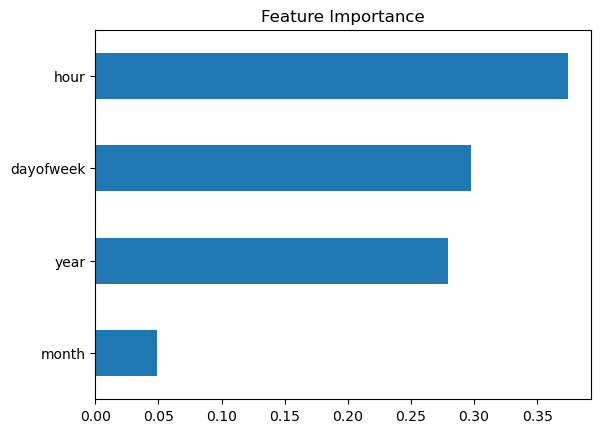

In [33]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=x_train.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

In [34]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Use the best estimator from your GridSearch to make predictions
y_pred = grid_search.best_estimator_.predict(x_test)

# 2. Calculate standard regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance on Test Set ---")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")

--- Model Performance on Test Set ---
R-squared: 0.8589
Mean Absolute Error (MAE): 0.06%
Root Mean Squared Error (RMSE): 0.13%


Best Hyperparameters: {'ccp_alpha': np.float64(3.251363794859796e-08), 'min_samples_leaf': 20}
Tree Depth: 17
Number of Leaves: 273


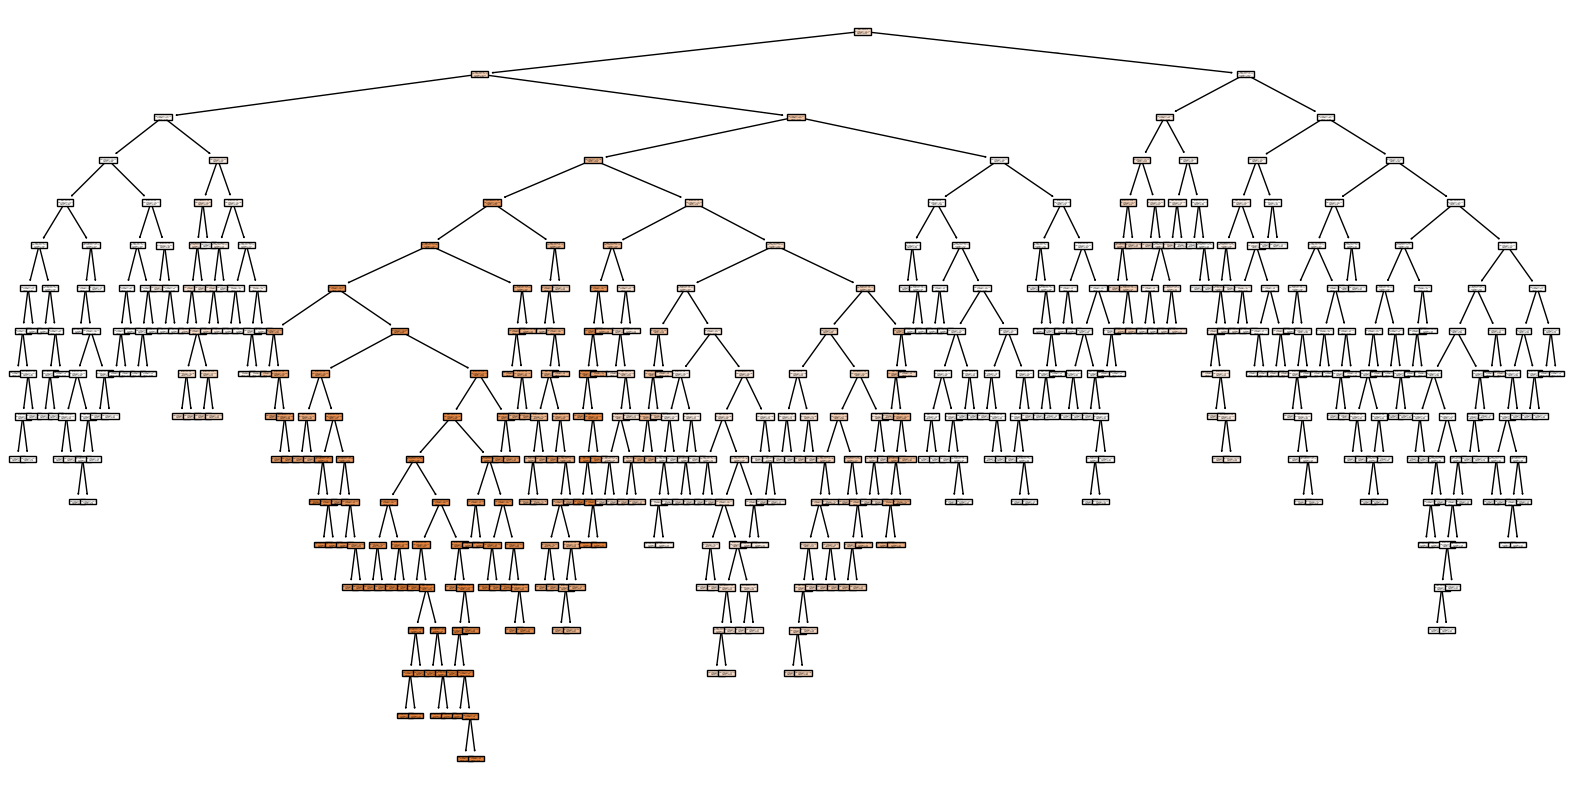

In [36]:

print("Best Hyperparameters:", grid_search.best_params_)
print(f"Tree Depth: {grid_search.best_estimator_.get_depth()}")
print(f"Number of Leaves: {grid_search.best_estimator_.get_n_leaves()}")
# Plot the actual tree
plt.figure(figsize=(20,10))
plot_tree(grid_search.best_estimator_, feature_names=x_train.columns, filled=True)
plt.show()

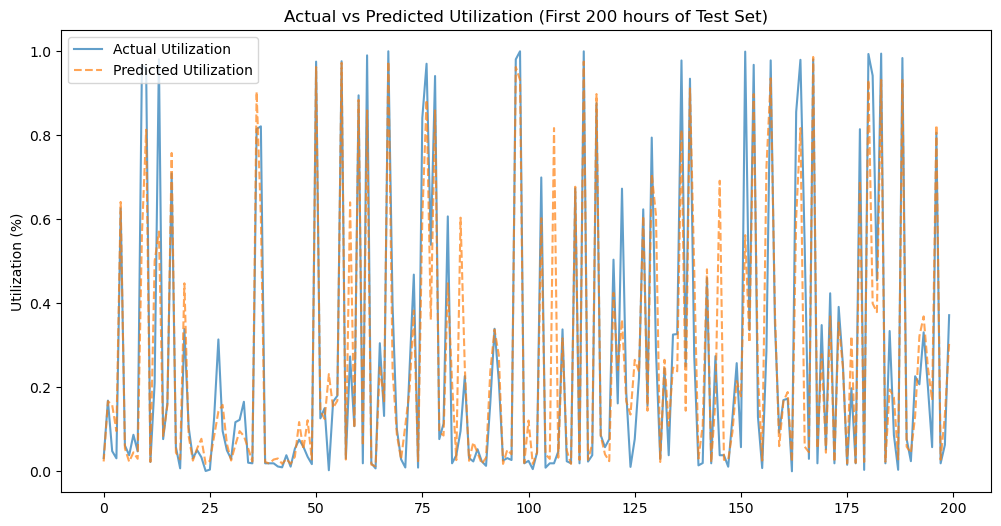

In [ ]:
# 3. Quick visualization: Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label='Actual Utilization', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Utilization', alpha=0.7, linestyle='--')
plt.title('Actual vs Predicted Utilization (First 200 hours of Test Set)')
plt.ylabel('Utilization (%)')
plt.legend()
plt.show()

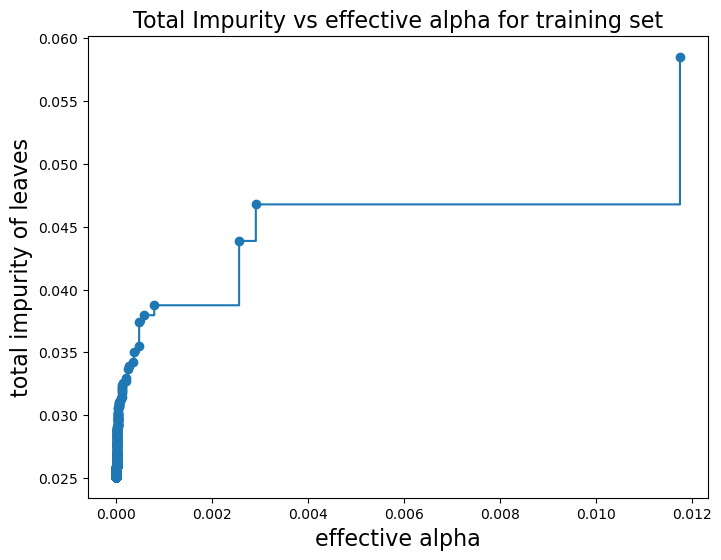

In [ ]:
# plot cost_complexity_pruning_path
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")  # we remove the last alpha as this corresponds to a tree with only the root node
ax.set_xlabel("effective alpha",fontsize=16)
ax.set_ylabel("total impurity of leaves",fontsize=16)
ax.set_title("Total Impurity vs effective alpha for training set",fontsize=16)
plt.show()

## c) Concrete Example of Application

TODO